In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ["PATH"] = "/mnt/lustre-grete/usr/u12045/projects/LLAVA-Med/envs/lerobot/bin:" + os.environ.get("PATH", "")
os.environ["HF_HOME"] = "/mnt/lustre-grete/usr/u12045/vla/hf_cache"
os.environ["TMPDIR"] = "/mnt/lustre-grete/usr/u12045/vla/cache"
os.environ["PYTHONPATH"] = "/mnt/lustre-grete/usr/u12045/vla/duci/VLA-Humanoid:" + os.environ.get("PYTHONPATH", "")


%load_ext autoreload
%autoreload 2

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import glob
import ast
from PIL import Image, ImageDraw

In [3]:
import h5py
data_path = './libero_10_mask_depth_noops/' + 'KITCHEN_SCENE4_put_the_black_bowl_in_the_bottom_drawer_of_the_cabinet_and_close_it_demo.hdf5'
f = h5py.File(data_path, 'r')
data = f['data']

In [3]:
data['demo_0']['obs'].keys()

<KeysViewHDF5 ['agentview_depths', 'agentview_mask', 'agentview_rgb', 'ee_ori', 'ee_pos', 'ee_states', 'eye_in_hand_depths', 'eye_in_hand_mask', 'eye_in_hand_rgb', 'gripper_states', 'joint_states', 'mask_object_id', 'object_of_interest']>

In [5]:
np.unique(data['demo_1']['obs']['agentview_mask'][:][0])

array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32)

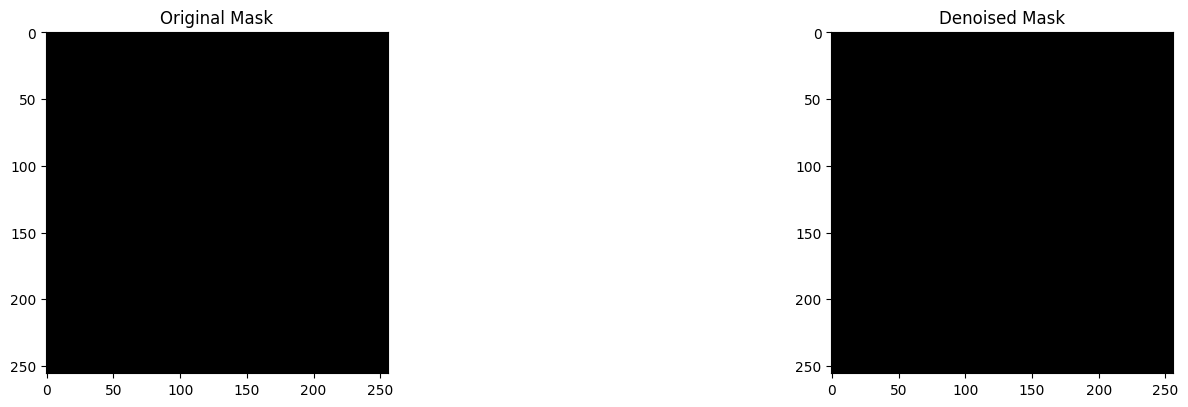

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_opening

# Binary mask: class == 10 → True, others → False
binary_mask = np.squeeze(data['demo_1']['obs']['agentview_mask'][:][226]==1).astype(bool)

# Apply light morphological opening
structure = np.ones((2, 2), dtype=bool)
denoised_mask = binary_opening(binary_mask, structure=structure)

# Visualize
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original Mask")
plt.imshow(binary_mask, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Denoised Mask")
plt.imshow(denoised_mask, cmap='gray')

plt.tight_layout()
plt.show()


In [ ]:
import glob
import numpy as np
import ast
from PIL import Image
import h5py
from scipy.ndimage import binary_opening
import random

def rename_obj(obj, relevant_objects):
    if obj == 'akita_black_bowl_1':
        obj = 'black_bowl_1'
    elif obj == 'white_cabinet_1':
        obj = 'cabinet_1'
    elif obj == 'white_yellow_mug_1':
        obj = 'yellow_and_white_mug_1'
    elif obj == 'black_book_1':
        obj = 'book_1'
    elif obj == 'desk_caddy_1':
        obj = 'caddy_1'
    elif obj == 'plate_1' and 'plate_2' in relevant_objects:
        obj = 'left_plate_1'
    elif obj == 'plate_2' and 'plate_1' in relevant_objects:
        obj = 'right_plate_1'
    elif obj == 'porcelain_mug_1':
        obj = 'white_mug_1'
    elif 'flat_stove_1' in obj:
        obj = 'stove_1'
    elif obj == 'moka_pot_1' and 'moka_pot_2' in relevant_objects:
        obj = 'left_moka_pot_1'
    elif obj == 'moka_pot_2' and 'moka_pot_1' in relevant_objects:
        obj = 'right_moka_pot_1'
    elif obj == 'wine_rack_1_top_region':
        obj = 'wine_rack_1'
    elif 'wooden_cabinet_1' in obj:
        obj = 'cabinet_1'
    elif obj == 'main_table_stove_front_region':
        obj = 'stove_1'
    return obj.replace('_1', '').replace('_', ' ')


train_dir = "/mnt/lustre-grete/usr/u12045/vla/duci/Open-GroundingDino/LIBERO_odvg/train"
all_files = glob.glob('./libero_10_mask_depth_noops/*.hdf5')
all_files += glob.glob('./libero_goal_mask_depth_noops/*.hdf5')
all_files += glob.glob('./libero_object_mask_depth_noops/*.hdf5')
all_files += glob.glob('./libero_spatial_mask_depth_noops/*.hdf5')
odvg_list = []

i = 0
for file in all_files:
    task = file.split("/")[-1].split('.')[0].replace('_demo','')
    if 'libero_10_mask_depth_noops' in file:
        pos = task.index('SCENE')
        task = task[pos+7:]
    f = h5py.File(file, 'r')
    all_demos = f['data']
    length = int(0.9 * len(all_demos))
    for key in list(all_demos.keys())[:length]:
        demo = all_demos[key]
        class_mapping = ast.literal_eval(demo['obs']['mask_object_id'].asstr()[()])
        relevant_objects = ast.literal_eval(demo['obs']['object_of_interest'].asstr()[()])

        for img_view in ['agentview_rgb', 'eye_in_hand_rgb']:
            all_frames = demo['obs'][img_view][:]
            all_frames_mask = demo['obs'][img_view.replace('rgb', 'mask')][:]
            indices = random.sample(range(len(all_frames)), 2)
            for view_idx in indices:
                single_frame_img = all_frames[view_idx]
                single_frame_img = single_frame_img
                pil_image = Image.fromarray(single_frame_img)

                filename = f"eps{i}_{img_view}_frame{view_idx}.png"
                pil_image.save(f"{train_dir}/{filename}")

                ### Extract visual grounding data
                regions = []
                single_frame_mask = np.squeeze(all_frames_mask[view_idx])
                for obj in relevant_objects:
                    if obj == 'main_table_stove_front_region':
                        obj = 'flat_stove_1'
                    elif '1' in obj and obj.index('1') != len(obj)-1:
                        obj = obj[:obj.index('1')+1]
                        
                    obj_mask = single_frame_mask == int(class_mapping[obj])
                    structure = np.ones((2, 2), dtype=bool)
                    obj_mask_smooth = binary_opening(obj_mask, structure=structure)
                    ys, xs = np.where(obj_mask_smooth)
                    if ys.size == 0 or xs.size == 0:
                        bbox = None  # no object found                        
                    else:
                        x_min = xs.min()
                        y_min = ys.min()
                        x_max = xs.max()
                        y_max = ys.max()
                        bbox = [int(x_min), int(y_min), int(x_max), int(y_max)]
                        
                        newname_obj = rename_obj(obj, relevant_objects)
                        regions.append({
                            'bbox': bbox,
                            'phrase': newname_obj
                        })

                odvg_list.append({
                    "filename": filename,
                    "height": pil_image.height,
                    "width": pil_image.width,
                    "grounding": {
                        "caption": task.replace('_', ' '),
                        "regions": regions
                    }
                })
        i += 1
    

import json

output_path = f"{train_dir}/odvg_annotations.json"
with open(output_path, 'w') as f:
    json.dump(odvg_list, f, indent=2)

## vislize bbox with odvg annotation

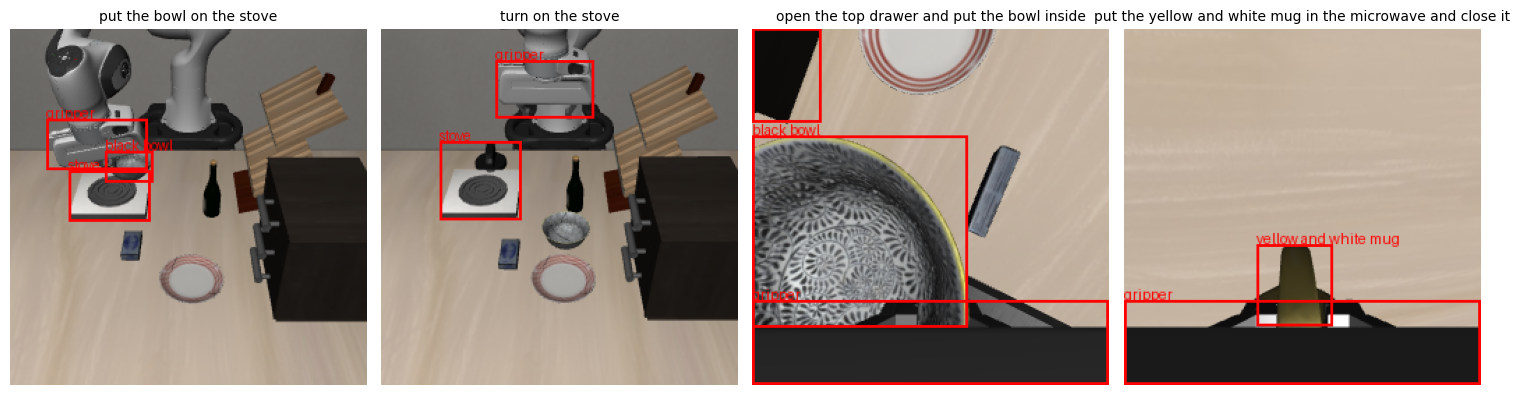

In [3]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import random
import json

# Load your annotations
train_dir = "/mnt/lustre-grete/usr/u12045/vla/duci/Open-GroundingDino/LIBERO_odvg/train"
with open(f"{train_dir}/odvg_annotations.json", 'r') as f:
    annotations = json.load(f)

# Pick N examples to visualize
n_visualize = 3
examples = random.sample(annotations, k=n_visualize)
examples += [annotations[150]]



# Set up the grid layout (2 rows x 3 cols)
ncols = 4
nrows = (n_visualize + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 8))
axes = axes.flatten()

for ax, ann in zip(axes, examples):
    image_path = f"{train_dir}/{ann['filename']}"
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    for region in ann['grounding']['regions']:
        bbox = region['bbox']
        phrase = region['phrase']
        if bbox is not None:
            draw.rectangle(bbox, outline='red', width=2)
            draw.text((bbox[0], bbox[1]-10), phrase, fill='red')

    ax.imshow(img)
    ax.set_title(ann['grounding']['caption'], fontsize=10)
    ax.axis('off')

# Hide any unused axes if n_visualize < nrows*ncols
for i in range(n_visualize, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import os, glob, json, ast, h5py
import numpy as np
from PIL import Image
from scipy.ndimage import binary_opening
import random

def rename_obj(obj, relevant_objects):
    if obj == 'akita_black_bowl_1':
        obj = 'black_bowl_1'
    elif obj == 'white_cabinet_1':
        obj = 'cabinet_1'
    elif obj == 'white_yellow_mug_1':
        obj = 'yellow_and_white_mug_1'
    elif obj == 'black_book_1':
        obj = 'book_1'
    elif obj == 'desk_caddy_1':
        obj = 'caddy_1'
    elif obj == 'plate_1' and 'plate_2' in relevant_objects:
        obj = 'left_plate_1'
    elif obj == 'plate_2' and 'plate_1' in relevant_objects:
        obj = 'right_plate_1'
    elif obj == 'porcelain_mug_1':
        obj = 'white_mug_1'
    elif 'flat_stove_1' in obj:
        obj = 'stove_1'
    elif obj == 'moka_pot_1' and 'moka_pot_2' in relevant_objects:
        obj = 'left_moka_pot_1'
    elif obj == 'moka_pot_2' and 'moka_pot_1' in relevant_objects:
        obj = 'right_moka_pot_1'
    elif obj == 'wine_rack_1_top_region':
        obj = 'wine_rack_1'
    elif 'wooden_cabinet_1' in obj:
        obj = 'cabinet_1'
    elif obj == 'main_table_stove_front_region':
        obj = 'stove_1'
    return obj.replace('_1', '').replace('_', ' ')

val_dir = "/mnt/lustre-grete/usr/u12045/vla/duci/Open-GroundingDino/LIBERO_odvg/val"
os.makedirs(val_dir, exist_ok=True)

all_files = glob.glob('./libero_10_mask_depth_noops/*.hdf5')
all_files += glob.glob('./libero_goal_mask_depth_noops/*.hdf5')
all_files += glob.glob('./libero_object_mask_depth_noops/*.hdf5')
all_files += glob.glob('./libero_spatial_mask_depth_noops/*.hdf5')

images = []
annotations = []
categories = []
cat_name_to_id = {}

image_id = 1
ann_id = 1
i = 0

for file in all_files:
    task = file.split("/")[-1].split('.')[0].replace('_demo','')
    if 'libero_10_mask_depth_noops' in file:
        pos = task.index('SCENE')
        task = task[pos+7:]
    f = h5py.File(file, 'r')
    all_demos = f['data']
    length = int(0.9 * len(all_demos))
    for key in list(all_demos.keys())[length:]:
        demo = all_demos[key]
        class_mapping = ast.literal_eval(demo['obs']['mask_object_id'].asstr()[()])
        relevant_objects = ast.literal_eval(demo['obs']['object_of_interest'].asstr()[()])

        for img_view in ['agentview_rgb', 'eye_in_hand_rgb']:
            all_frames = demo['obs'][img_view][:]
            all_frames_mask = demo['obs'][img_view.replace('rgb', 'mask')][:]
            indices = random.sample(range(len(all_frames)), 2)
            for view_idx in indices:
                single_frame_img = all_frames[view_idx]
                pil_image = Image.fromarray(single_frame_img)

                filename = f"eps{i}_{img_view}_frame{view_idx}.png"
                pil_image.save(f"{val_dir}/{filename}")

                # COCO image entry
                images.append({
                    "id": image_id,
                    "file_name": filename,
                    "height": pil_image.height,
                    "width": pil_image.width
                })

                # Extract annotations
                single_frame_mask = np.squeeze(all_frames_mask[view_idx])
                for obj in relevant_objects:
                    # normalize like your ODVG code
                    if obj == 'main_table_stove_front_region':
                        obj_key = 'flat_stove_1'
                    elif '1' in obj and obj.index('1') != len(obj)-1:
                        obj_key = obj[:obj.index('1')+1]
                    else:
                        obj_key = obj

                    # category name (human-readable)
                    # cat_name = obj_key.replace('_1','').replace('_',' ').strip()
                    cat_name = rename_obj(obj_key, relevant_objects)
                    # category id (global)
                    if cat_name not in cat_name_to_id:
                        cat_id = len(cat_name_to_id) + 1
                        cat_name_to_id[cat_name] = cat_id
                        categories.append({
                            "id": cat_id,
                            "name": cat_name,
                            "supercategory": "libero"
                        })
                    else:
                        cat_id = cat_name_to_id[cat_name]

                    # mask id lookup (be tolerant to keys with/without _1)
                    mask_id = int(class_mapping[obj_key])
                    if mask_id is None:
                        print('huhu?')
                        continue

                    obj_mask = (single_frame_mask == mask_id)
                    structure = np.ones((2, 2), dtype=bool)
                    obj_mask_smooth = binary_opening(obj_mask, structure=structure)

                    ys, xs = np.where(obj_mask_smooth)
                    if ys.size == 0 or xs.size == 0:
                        continue
                    x_min = int(xs.min())
                    y_min = int(ys.min())
                    x_max = int(xs.max())
                    y_max = int(ys.max())
                    w = int(x_max - x_min + 1)
                    h = int(y_max - y_min + 1)

                    annotations.append({
                        "id": ann_id,
                        "image_id": image_id,
                        "category_id": cat_id,
                        "bbox": [x_min, y_min, w, h],  # COCO: [x, y, width, height]
                        "area": float(w * h),
                        "iscrowd": 0,
                        "segmentation": None
                    })
                    ann_id += 1

                image_id += 1

    i += 1
    f.close()

coco_dict = {
    "info": "None",
    "images": images,
    "annotations": annotations,
    "categories": categories
}

output_path = f"{val_dir}/libero_coco_format.json"
with open(output_path, 'w') as f:
    json.dump(coco_dict, f, indent=2)

# ---------- NEW: save label_map ----------
# Use a stable alphabetical order (0-based, string keys -> class names)
all_class_names = sorted([c["name"] for c in categories])
label_map = {str(i): name for i, name in enumerate(all_class_names)}
label_map_path = os.path.join(val_dir, "label_map.json")
with open(label_map_path, "w") as f:
    json.dump(label_map, f, indent=2, ensure_ascii=False)


print(f"Saved COCO JSON to: {output_path}")
print(f"Images: {len(images)}  Annotations: {len(annotations)}  Categories: {len(categories)}")


Saved COCO JSON to: /mnt/lustre-grete/usr/u12045/vla/duci/Open-GroundingDino/LIBERO_odvg/val/libero_coco_format.json
Images: 740  Annotations: 2140  Categories: 28


In [5]:
coco_dict.keys()

dict_keys(['info', 'images', 'annotations', 'categories'])

In [8]:
coco_dict['annotations']

[{'id': 1,
  'image_id': 1,
  'category_id': 1,
  'bbox': [123, 161, 39, 32],
  'area': 1248.0,
  'iscrowd': 0,
  'segmentation': None},
 {'id': 2,
  'image_id': 1,
  'category_id': 2,
  'bbox': [0, 89, 113, 115],
  'area': 12995.0,
  'iscrowd': 0,
  'segmentation': None},
 {'id': 3,
  'image_id': 1,
  'category_id': 3,
  'bbox': [91, 24, 71, 42],
  'area': 2982.0,
  'iscrowd': 0,
  'segmentation': None},
 {'id': 4,
  'image_id': 2,
  'category_id': 1,
  'bbox': [60, 108, 44, 36],
  'area': 1584.0,
  'iscrowd': 0,
  'segmentation': None},
 {'id': 5,
  'image_id': 2,
  'category_id': 2,
  'bbox': [0, 89, 113, 115],
  'area': 12995.0,
  'iscrowd': 0,
  'segmentation': None},
 {'id': 6,
  'image_id': 2,
  'category_id': 3,
  'bbox': [58, 68, 60, 53],
  'area': 3180.0,
  'iscrowd': 0,
  'segmentation': None},
 {'id': 7,
  'image_id': 3,
  'category_id': 1,
  'bbox': [75, 0, 61, 40],
  'area': 2440.0,
  'iscrowd': 0,
  'segmentation': None},
 {'id': 8,
  'image_id': 3,
  'category_id': 2,
 

In [5]:
all_class_names

['alphabet soup',
 'basket',
 'bbq sauce',
 'black bowl',
 'book',
 'butter',
 'cabinet',
 'caddy',
 'chocolate pudding',
 'cream cheese',
 'gripper',
 'ketchup',
 'left moka pot',
 'left plate',
 'microwave',
 'milk',
 'moka pot',
 'orange juice',
 'plate',
 'right moka pot',
 'right plate',
 'salad dressing',
 'stove',
 'tomato sauce',
 'white mug',
 'wine bottle',
 'wine rack',
 'yellow and white mug']

### Show bbox in final format

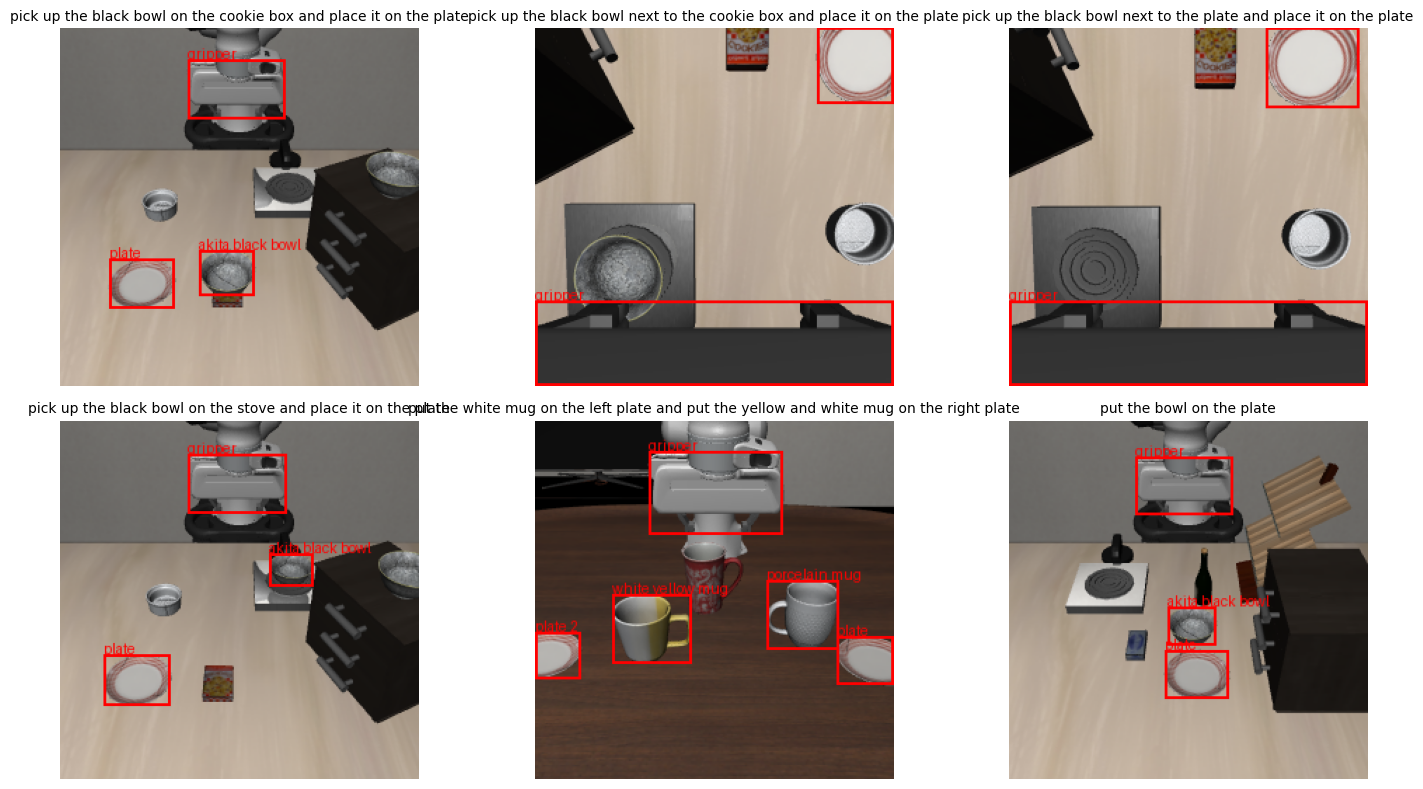

In [10]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import random
import json

# Load your annotations
with open(f"{train_dir}/odvg_annotations.json", 'r') as f:
    annotations = json.load(f)

# Pick N examples to visualize
n_visualize = 6
examples = random.sample(annotations, k=n_visualize)

# Set up the grid layout (2 rows x 3 cols)
ncols = 3
nrows = (n_visualize + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 8))
axes = axes.flatten()

for ax, ann in zip(axes, examples):
    image_path = f"{train_dir}/{ann['filename']}"
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    for region in ann['grounding']['regions']:
        bbox = region['bbox']
        phrase = region['phrase']
        if bbox is not None:
            draw.rectangle(bbox, outline='red', width=2)
            draw.text((bbox[0], bbox[1]-10), phrase, fill='red')

    ax.imshow(img)
    ax.set_title(ann['grounding']['caption'], fontsize=10)
    ax.axis('off')

# Hide any unused axes if n_visualize < nrows*ncols
for i in range(n_visualize, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


## Create mapping prompt task -> main objs

In [10]:
import glob
import h5py
import pandas as pd
import ast


def rename_obj(obj, relevant_objects):
    if obj == 'akita_black_bowl_1':
        obj = 'black_bowl_1'
    elif obj == 'white_cabinet_1':
        obj = 'cabinet_1'
    elif obj == 'white_yellow_mug_1':
        obj = 'yellow_and_white_mug_1'
    elif obj == 'black_book_1':
        obj = 'book_1'
    elif obj == 'desk_caddy_1':
        obj = 'caddy_1'
    elif obj == 'plate_1' and 'plate_2' in relevant_objects:
        obj = 'left_plate_1'
    elif obj == 'plate_2' and 'plate_1' in relevant_objects:
        obj = 'right_plate_1'
    elif obj == 'porcelain_mug_1':
        obj = 'white_mug_1'
    elif 'flat_stove_1' in obj:
        obj = 'stove_1'
    elif obj == 'moka_pot_1' and 'moka_pot_2' in relevant_objects:
        obj = 'left_moka_pot_1'
    elif obj == 'moka_pot_2' and 'moka_pot_1' in relevant_objects:
        obj = 'right_moka_pot_1'
    elif obj == 'wine_rack_1_top_region':
        obj = 'rack_1'
    elif 'wooden_cabinet_1' in obj:
        obj = 'cabinet_1'
    elif obj == 'main_table_stove_front_region':
        obj = 'stove_1'
    return obj.replace('_1', '').replace('_', ' ')

all_files = glob.glob('./libero_10_mask_depth_noops/*.hdf5')
all_files += glob.glob('./libero_goal_mask_depth_noops/*.hdf5')
all_files += glob.glob('./libero_object_mask_depth_noops/*.hdf5')
all_files += glob.glob('./libero_spatial_mask_depth_noops/*.hdf5')

records = []

for file in all_files:
    task = file.split("/")[-1].split('.')[0].replace('_demo', '')
    if 'libero_10_mask_depth_noops' in file:
        pos = task.index('SCENE')
        task = task[pos+7:]

    
    with h5py.File(file, 'r') as f:
        all_demos = f['data']
        # Extract object_of_interest from first demo
        first_key = list(all_demos.keys())[0]
        OOI = all_demos[first_key]['obs']['object_of_interest'].asstr()[()]
    OOI = ast.literal_eval(OOI)
    rename_OOI = [rename_obj(i, OOI) for i in OOI]
    records.append({'task': task.replace('_', ' '), 'object_of_interest': rename_OOI})
# Convert to DataFrame
df = pd.DataFrame(records)

In [9]:
task

'pick_up_the_black_bowl_on_the_ramekin_and_place_it_on_the_plate'

In [11]:
df.head()

,task,object_of_interest
0,put the black bowl in the bottom drawer of the...,"[black bowl, cabinet, gripper]"
1,put the yellow and white mug in the microwave ...,"[yellow and white mug, microwave, gripper]"
2,put both the alphabet soup and the cream chees...,"[alphabet soup, cream cheese, basket, gripper]"
3,pick up the book and place it in the back comp...,"[book, caddy, gripper]"
4,put both the alphabet soup and the tomato sauc...,"[alphabet soup, tomato sauce, basket, gripper]"


In [13]:
df.to_csv('libero_mapping_task_ooi.csv', index=False)

In [14]:
df['task']

0     put the black bowl in the bottom drawer of the...
1     put the yellow and white mug in the microwave ...
2     put both the alphabet soup and the cream chees...
3     pick up the book and place it in the back comp...
4     put both the alphabet soup and the tomato sauc...
5     put the white mug on the left plate and put th...
6          turn on the stove and put the moka pot on it
7                       put both moka pots on the stove
8     put the white mug on the plate and put the cho...
9     put both the cream cheese box and the butter i...
10                            put the bowl on the plate
11                      put the wine bottle on the rack
12                     put the cream cheese in the bowl
13          open the top drawer and put the bowl inside
14             push the plate to the front of the stove
15                open the middle drawer of the cabinet
16                   put the bowl on top of the cabinet
17            put the wine bottle on top of the 

In [15]:
data = df[df['task'] == 'put the wine bottle on the rack']['object_of_interest']

,task,object_of_interest
11,put the wine bottle on the rack,"[wine bottle, rack, gripper]"
